# Fase 5 — Self-Play Mixt i Mètriques d'Explotabilitat

**Continuació de:** [`comparacio_fase4.ipynb`](../4_memoria/comparacio_fase4.ipynb)

Aquest notebook analitza la Fase 5 del TFG. Els fonaments teòrics es troben a [`17_Fase5_MarcTeoric`](../../17_Fase5_MarcTeoric.md) i els detalls d'implementació a [`18_Fase5_Implementacio`](../../18_Fase5_Implementacio.md).

> **Q4:** Pot el self-play mixt reduir l'explotabilitat del PPO sense degradar el rendiment global?

## Disseny experimental

| Run | Agent | Punt inicial | Pool oponents | Steps | Mètriques |
|:--|:--|:--|:--|--:|:--|
| **F4-ablació-48M (baseline)** | PPO + COS frozen | Scratch | 6 AgentRegles (fix) | 48M | metric + metric\_robust per variant |
| **F5-selfplay** | PPO + COS frozen | F4-ablació-48M best.zip | 6 AgentRegles + 9 snapshots | 48M | metric + metric\_robust + exploit\_selfplay |

**Hipòtesis:**
- **H1**: Self-play no degrada WR global: `max metric F5@≤48M >= max F4@≤48M − 3 pp`
- **H2**: Self-play millora robustesa: `metric_robust F5 pic > metric_robust F4-48M best.zip`
- **H3**: `exploit_selfplay` final `< 10 pp` (convergència cap a Nash)

### Distribució de l'Entrenament (Regles vs Self-Play)

Com es pot veure a la taula, a la **Fase 5** la pool d'oponents està formada per 6 agents basats en regles (de la Fase 4) i fins a 9 *snapshots* del mateix agent aprenent.

El codi encarregat de seleccionar l'oponent (`pool_selfplay.py`) escull **de forma uniforme** (`random.choice`) entre el total d'agents disponibles a la pool (agents de regles + els *snapshots* històrics disponibles). Això provoca una distribució de l'entrenament molt interessant:

- **A l'inici (0 snapshots):** L'agent s'entrena **100%** contra els 6 agents de regles.
- **En progrés (ex. 3 snapshots):** La probabilitat de jugar contra regles baixa al **66%** (6/9) i el *self-play* suposa un 33%.
- **Pool plena (9 snapshots):** La proporció d'entrenament contra regles es redueix al **40%** (6/15), i la majoria de l'entrenament passa a ser *self-play* **(60%)**.

Aquest enfocament dinàmic actua com una espècie de *curriculum learning*: primer s'aprèn a explotar les polítiques estàtiques, i a mesura que l'agent assoleix més nivell (i per tant els seus *snapshots* també), es fa més èmfasi en combatre contra versions competents de si mateix per evitar l'estancament i augmentar-ne la robustesa.

---
## 1. Setup

In [13]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot, suavitzar, step_first_above

setup_pyplot()

BASE = Path('../../../')

MAX_STEPS_COMPARA = 48e6   # tall per comparació F4-48M vs F5-48M

RUNS = {
    'f4_ablacio_48M': {
        'path':  BASE / 'TFG_Doc/notebooks/5_selfplay/resultats/ppo_ablacio_pool_48M/training_log.csv',
        'label': 'F4-ablació (48M)',
        'color': '#e67e22', 'ls': '--', 'lw': 1.8,
        'note':  'baseline — mateix protocol que F5',
    },
    'f5_selfplay': {
        'path':  BASE / 'TFG_Doc/notebooks/5_selfplay/resultats/ppo_selfplay_pool_9snaps/training_log.csv',
        'label': 'F5-selfplay (9 snaps, 48M)',
        'color': '#3498db', 'ls': '-', 'lw': 2.4,
        'note':  'self-play mixt',
    },
}

VARIANTS = ['conservador', 'agressiu', 'truc_bot', 'envit_bot', 'faroler', 'equilibrat']

print('Setup completat.')
print(f'Directori base: {BASE.resolve()}')
print(f'Tall comparatiu: {MAX_STEPS_COMPARA/1e6:.0f}M steps')


Setup completat.
Directori base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc
Tall comparatiu: 48M steps


---
## 2. Càrrega de dades

In [12]:
dades = {}
for key, info in RUNS.items():
    p = info['path']
    if p.exists():
        df = pd.read_csv(p)
        dades[key] = df
        pic  = df['metric'].max()
        step = df['step'].max() / 1e6
        print(f"  {info['label']:<35}: {len(df):>3} aval.  max step={step:.1f}M  pic metric={pic:.1f}%")
    else:
        print(f"  {info['label']:<35}: (pendent — {info.get('note', '')})")

if not dades:
    print('\nCap dada disponible.')

  F4-ablació (48M)                   :  96 aval.  max step=48.0M  pic metric=89.0%
  F5-selfplay (9 snaps, 48M)         :  96 aval.  max step=48.0M  pic metric=89.2%


---
## 3. Anàlisi numèrica i validació d'hipòtesis

In [26]:
import random as _random

_root = str(BASE.resolve())
if _root not in sys.path:
    sys.path.insert(0, _root)

from stable_baselines3 import PPO as _PPO
from RL.models.sb3.sb3_features_extractor import CosMultiInputSB3 as _CosExt
from RL.entrenament.entrenamentsComparatius.fase2.entrenament_fase2_curriculum import (
    ENV_CONFIG as _ENV_CONFIG, SB3EvalAgent as _SB3EvalAgent,
)
from RL.entrenament.entrenamentsComparatius.fase4.pool_oponents import (
    NOMS_VARIANTS as _NOMS_VARIANTS, crear_oponent as _crear_oponent,
)
from joc.entorn.env import TrucEnv as _TrucEnv

_LAMBDA_STD = 0.5
_N_SES      = 20
_SEED_EVAL  = 54321


def _load_model(ruta):
    _orig = _PPO.set_parameters
    def _patch(self, load_path_or_dict, exact_match=True, device="auto"):
        if isinstance(load_path_or_dict, dict):
            load_path_or_dict = {k: v for k, v in load_path_or_dict.items()
                                 if "optimizer" not in k}
        return _orig(self, load_path_or_dict, exact_match=False, device=device)
    _PPO.set_parameters = _patch
    try:
        model = _PPO.load(str(ruta),
                          custom_objects={"features_extractor_class": _CosExt},
                          device="cpu")
    finally:
        _PPO.set_parameters = _orig
    return model


def _jugar(agent, oponent, rng):
    cfg = _ENV_CONFIG.copy()
    cfg['seed'] = rng.randint(0, 2**31 - 1)
    env = _TrucEnv(cfg)
    env.set_agents([agent, oponent])
    state, pid = env.reset()
    while pid is not None:
        a, _ = (agent if pid == 0 else oponent).eval_step(state)
        state, pid = env.step(a)
    return env.game.get_payoffs()[0] > 0


def _avaluar_variants(model_path, label):
    print(f"Avaluant {label}…")
    model = _load_model(model_path)
    agent = _SB3EvalAgent(model)
    rng   = _random.Random(_SEED_EVAL)
    res   = {}
    for nom in _NOMS_VARIANTS:
        wins = sum(
            int(_jugar(agent, _crear_oponent(nom, seed=rng.randint(0, 2**31-1)), rng))
            for _ in range(_N_SES)
        )
        res[nom] = 100.0 * wins / _N_SES
        print(f"  {nom:<15}: {res[nom]:.1f}%")
    vals = list(res.values())
    mean = float(np.mean(vals))
    std  = float(np.std(vals))
    mr   = mean - _LAMBDA_STD * std
    print(f"  WR_pool_mean={mean:.1f}%  std={std:.1f}%  metric_robust={mr:.1f}%\n")
    return res, mean, std, mr


# Avaluació puntual de F4-ablació 48M best.zip — baseline principal per a H2
wr_f4_variants   = {}
f4_metric_robust = float('nan')
f4_std_pool      = float('nan')
f4_pool_mean_val = float('nan')

F4_48M_BEST = BASE / 'TFG_Doc/notebooks/5_selfplay/resultats/ppo_ablacio_pool_48M/best.zip'
if F4_48M_BEST.exists():
    wr_f4_variants, f4_pool_mean_val, f4_std_pool, f4_metric_robust = \
        _avaluar_variants(F4_48M_BEST, 'F4-ablació 48M best.zip')
else:
    print(f"No trobat: {F4_48M_BEST}")

print("\n" + "-"*40 + "\n")

# Avaluació puntual de F5-selfplay
wr_f5_variants    = {}
f5_metric_robust  = float('nan')
f5_std_pool       = float('nan')
f5_pool_mean_val  = float('nan')

F5_48M_BEST = BASE / 'TFG_Doc/notebooks/5_selfplay/resultats/ppo_selfplay_pool_9snaps/best.zip'
if F5_48M_BEST.exists():
    wr_f5_variants, f5_pool_mean_val, f5_std_pool, f5_metric_robust = \
        _avaluar_variants(F5_48M_BEST, 'F5-selfplay')
else:
    print(f"No trobat: {F5_48M_BEST}")


Avaluant F4-ablació 48M best.zip…
  conservador    : 75.0%
  agressiu       : 55.0%
  truc_bot       : 55.0%
  envit_bot      : 80.0%
  faroler        : 50.0%
  equilibrat     : 80.0%
  WR_pool_mean=65.8%  std=12.7%  metric_robust=59.5%


----------------------------------------

Avaluant F5-selfplay…
  conservador    : 55.0%
  agressiu       : 80.0%
  truc_bot       : 85.0%
  envit_bot      : 85.0%
  faroler        : 80.0%
  equilibrat     : 90.0%
  WR_pool_mean=79.2%  std=11.3%  metric_robust=73.5%



In [27]:
print("=" * 65)
for key, info in RUNS.items():
    df = dades.get(key)
    if df is None:
        print(f"{info['label']}: (sense dades)")
        continue
    pic       = df['metric'].max()
    step_pic  = df.loc[df['metric'].idxmax(), 'step'] / 1e6
    temps_h   = df['elapsed'].max() / 3600 if 'elapsed' in df.columns else float('nan')
    idx_pic   = df['metric'].idxmax()
    wr_r_pic  = df.loc[idx_pic, 'wr_random']
    wr_reg_pic = df.loc[idx_pic, 'wr_regles']

    print(f"\n{info['label']}")
    print(f"  Pic metric:        {pic:.1f}%  (step {step_pic:.1f}M)")
    print(f"  WR_random@pic:     {wr_r_pic:.1f}%")
    print(f"  WR_regles@pic:     {wr_reg_pic:.1f}%")
    print(f"  Temps total:       {temps_h:.2f}h")
    if 'metric_robust' in df.columns:
        mr_pic      = df['metric_robust'].max()
        step_mr_pic = df.loc[df['metric_robust'].idxmax(), 'step'] / 1e6
        std_min     = df['std_pool'].min()
        std_max     = df['std_pool'].max()
        print(f"  Pic metric_robust: {mr_pic:.1f}%  (step {step_mr_pic:.1f}M)")
        print(f"  std_pool rang:     [{std_min:.1f}%, {std_max:.1f}%]")
    if 'exploit_selfplay' in df.columns:
        valid = df['exploit_selfplay'].dropna()
        if not valid.empty:
            exp_final = valid.iloc[-5:].mean()
            exp_min   = valid.min()
            print(f"  exploit_sp final (mean últims 5): {exp_final:.1f} pp")
            print(f"  exploit_sp mínim:                 {exp_min:.1f} pp")

print("\n" + "=" * 65)
print("\nVALIDACIÓ HIPÒTESIS:")

df_f4_48M_log = dades.get('f4_ablacio_48M')
df_f5         = dades.get('f5_selfplay')

# h1
if df_f4_48M_log is not None and df_f5 is not None:
    f4_at_48M = float(df_f4_48M_log[df_f4_48M_log['step'] <= 48e6]['metric'].max())
    f5_at_48M = float(df_f5[df_f5['step'] <= 48e6]['metric'].max())
    h1_val = f5_at_48M >= (f4_at_48M - 3)
    print(f"\nH1 — F5 max metric@≤12M >= F4@≤48M - 3pp:")
    print(f"     F5={f5_at_48M:.1f}% vs F4={f4_at_48M:.1f}%  (llindar: {f4_at_48M-3:.1f}%): {'VALIDA' if h1_val else 'FALLA'}")

    # h2
    if df_f5 is not None and not np.isnan(f4_metric_robust):
        mr_f5_pic = df_f5['metric_robust'].max()
        mr_f5_fin = float(df_f5['metric_robust'].iloc[-1])
        delta_pic = mr_f5_pic - f4_metric_robust
        print(f"\nH2 — metric_robust F5 > metric_robust F4-48M best.zip:")
        print(f"     F4-48M={f4_metric_robust:.1f}%  |  F5 pic={mr_f5_pic:.1f}% (Δ={delta_pic:+.1f}pp)  |  F5 final={mr_f5_fin:.1f}%")
        print(f"     {'VALIDA' if mr_f5_pic > f4_metric_robust else 'FALLA'}")

    #h3
    if 'exploit_selfplay' in df_f5.columns:
        valid = df_f5['exploit_selfplay'].dropna()
        exp_final = valid.iloc[-5:].mean() if not valid.empty else float('nan')
        print(f"\nH3 — exploit_selfplay final < 10 pp:")
        print(f"     Mean últims 5 punts = {exp_final:.1f} pp: {'VALIDA' if exp_final < 10 else 'FALLA (cycling)'}")


F4-ablació (48M)
  Pic metric:        89.0%  (step 24.0M)
  WR_random@pic:     92.0%
  WR_regles@pic:     88.0%
  Temps total:       1.41h
  Pic metric_robust: 73.2%  (step 12.0M)
  std_pool rang:     [6.3%, 17.0%]

F5-selfplay (9 snaps, 48M)
  Pic metric:        89.2%  (step 41.5M)
  WR_random@pic:     96.0%
  WR_regles@pic:     87.0%
  Temps total:       1.69h
  Pic metric_robust: 77.8%  (step 39.5M)
  std_pool rang:     [6.1%, 18.6%]
  exploit_sp final (mean últims 5): 4.7 pp
  exploit_sp mínim:                 0.0 pp


VALIDACIÓ HIPÒTESIS:

H1 — F5 max metric@≤12M >= F4@≤48M - 3pp:
     F5=89.2% vs F4=89.0%  (llindar: 86.0%): VALIDA

H2 — metric_robust F5 > metric_robust F4-48M best.zip:
     F4-48M=59.5%  |  F5 pic=77.8% (Δ=+18.3pp)  |  F5 final=70.7%
     VALIDA

H3 — exploit_selfplay final < 10 pp:
     Mean últims 5 punts = 4.7 pp: VALIDA


---
## 4. Corbes d'aprenentatge

Comparació completa a 48M steps: F4-ablació-48M (baseline) vs F5-selfplay (48M).
Tots dos runs comparteixen el mateix protocol (n_partides=1, 32 envs) per a una comparació justa.


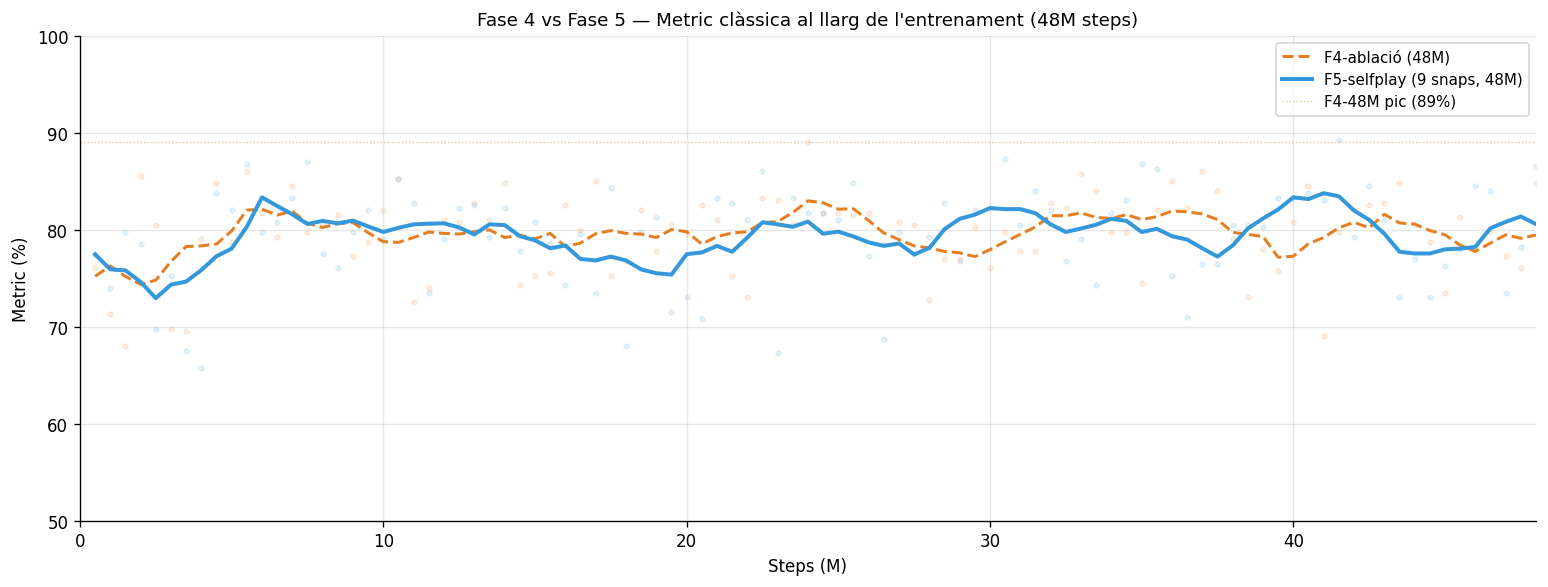

In [32]:
if dades:
    WINDOW = 7
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.set_title(
        'Fase 4 vs Fase 5 — Metric clàssica al llarg de l\'entrenament (48M steps)',
        fontsize=11
    )

    for key, info in RUNS.items():
        df = dades.get(key)
        if df is None:
            continue
        df_t = df[df['step'] <= MAX_STEPS_COMPARA]
        s = df_t['step'] / 1e6
        ax.scatter(s, df_t['metric'], color=info['color'], alpha=0.12, s=8)
        ax.plot(s, suavitzar(df_t['metric'], WINDOW),
                color=info['color'], linestyle=info['ls'],
                linewidth=info['lw'], label=info['label'])

    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('Metric (%)')
    ax.set_xlim(0, MAX_STEPS_COMPARA / 1e6)
    ax.set_ylim(50, 100)
    ax.axhline(89, color='#e67e22', linestyle=':', linewidth=0.8, alpha=0.5, label='F4-48M pic (89%)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Sense dades — cal executar els runs primer.')


### 4.1 Corba completa de F5 (48M steps)


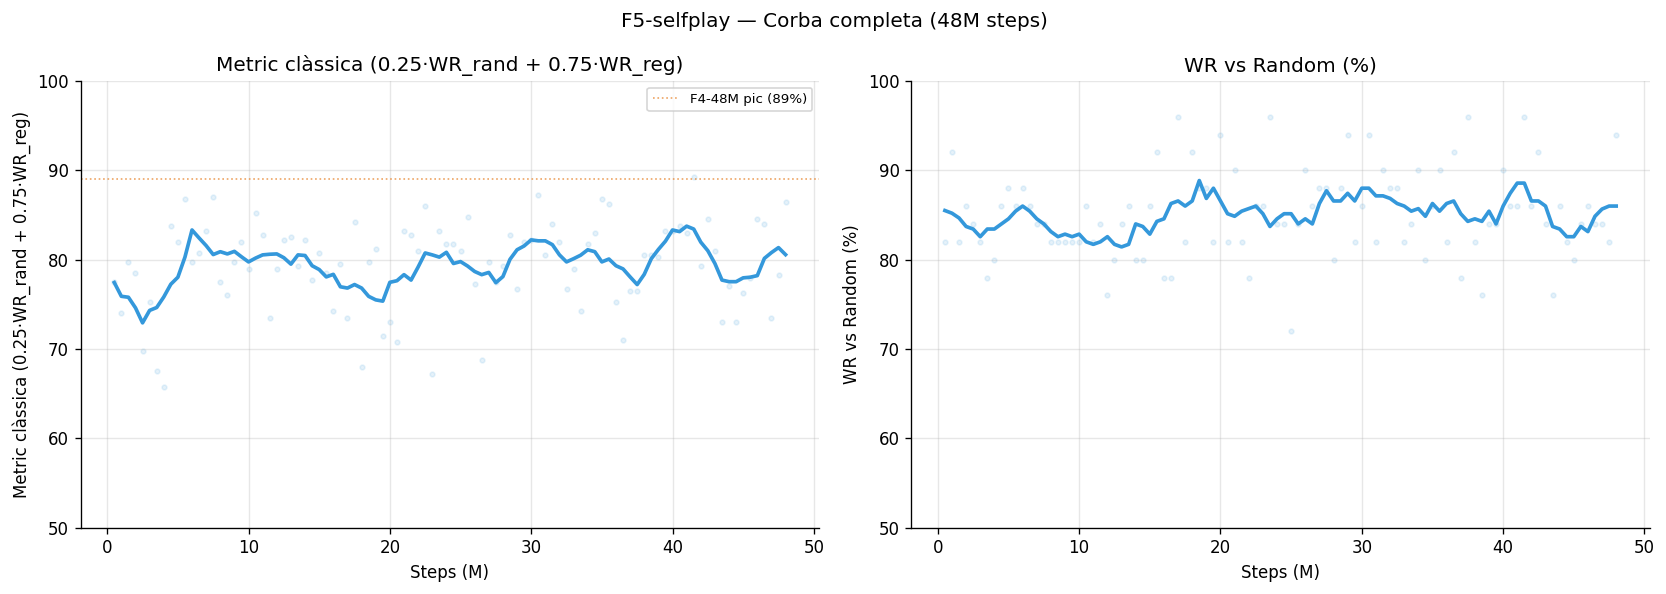

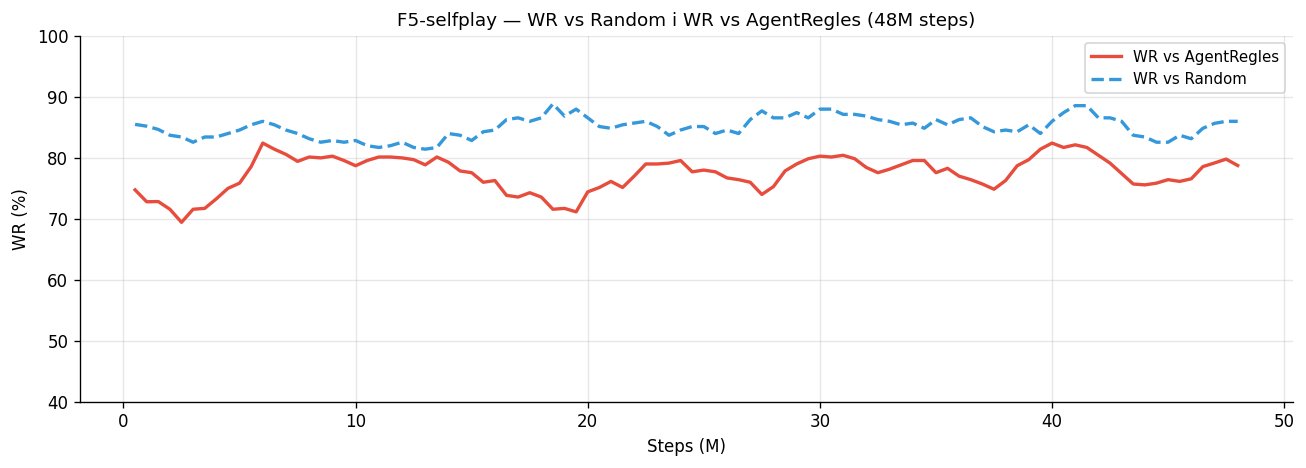

In [33]:
df_f5 = dades.get('f5_selfplay')
if df_f5 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('F5-selfplay — Corba completa (48M steps)', fontsize=12)

    for ax, (met, tit) in zip(axes, [
        ('metric',   'Metric clàssica (0.25·WR_rand + 0.75·WR_reg)'),
        ('wr_random', 'WR vs Random (%)'),
    ]):
        s = df_f5['step'] / 1e6
        col = RUNS['f5_selfplay']['color']
        ax.scatter(s, df_f5[met], color=col, alpha=0.12, s=8)
        ax.plot(s, suavitzar(df_f5[met], 7), color=col, linewidth=2.2)
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel(tit)
        ax.set_title(tit)
        ax.set_ylim(50, 100)

    axes[0].axhline(89, color='#e67e22', linestyle=':', linewidth=1, alpha=0.7, label='F4-48M pic (89%)')
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(11, 4))
    ax2.set_title('F5-selfplay — WR vs Random i WR vs AgentRegles (48M steps)', fontsize=11)
    s = df_f5['step'] / 1e6
    col = RUNS['f5_selfplay']['color']
    ax2.plot(s, suavitzar(df_f5['wr_regles'], 7),
             color='#e74c3c', linewidth=2.0, label='WR vs AgentRegles')
    ax2.plot(s, suavitzar(df_f5['wr_random'], 7),
             color=col, linewidth=2.0, linestyle='--', label='WR vs Random')
    ax2.set_xlabel('Steps (M)')
    ax2.set_ylabel('WR (%)')
    ax2.set_ylim(40, 100)
    ax2.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


---
## 5. Robustesa inter-estil

### 5.1 metric\_robust i std\_pool

`metric_robust = WR_pool_mean − 0.5 · std(WR_per_variant)` penalitza la dispersió entre estils.
- **std alta** : l'agent és especialitzat (guanya molt contra alguns estils, malament contra d'altres).
- **std baixa** : l'agent és equilibrat.

Ideal: `std : 0`, `metric_robust : WR_pool_mean`.

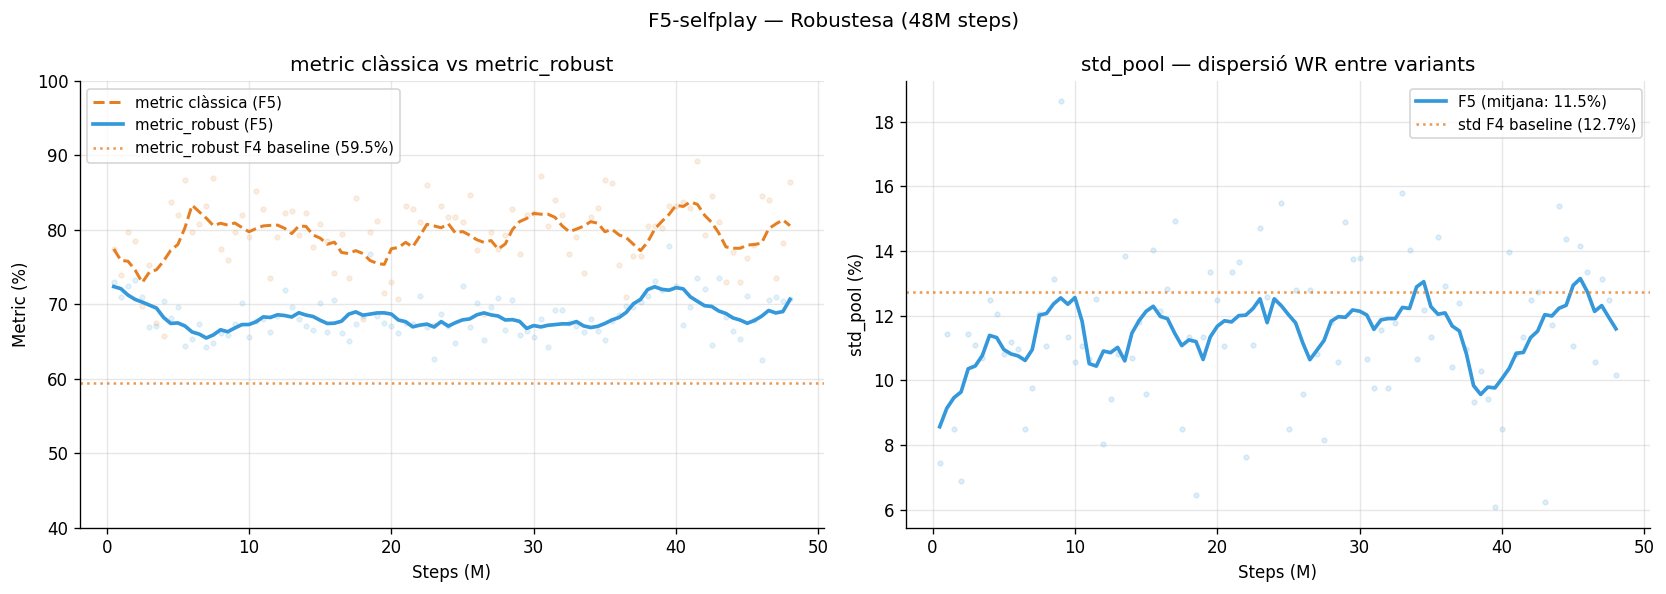

In [35]:
df_f5 = dades.get('f5_selfplay')
if df_f5 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('F5-selfplay — Robustesa (48M steps)', fontsize=12)
    s = df_f5['step'] / 1e6
    col = RUNS['f5_selfplay']['color']

    # metric clàssica vs metric_robust
    ax = axes[0]
    ax.scatter(s, df_f5['metric'],        color='#e67e22', alpha=0.12, s=8)
    ax.scatter(s, df_f5['metric_robust'], color=col,       alpha=0.12, s=8)
    ax.plot(s, suavitzar(df_f5['metric'],        7), color='#e67e22', linewidth=1.8,
            linestyle='--', label='metric clàssica (F5)')
    ax.plot(s, suavitzar(df_f5['metric_robust'], 7), color=col, linewidth=2.2,
            label='metric_robust (F5)')
    if not np.isnan(f4_metric_robust):
        ax.axhline(f4_metric_robust, color='#e67e22', linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'metric_robust F4 baseline ({f4_metric_robust:.1f}%)')
    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('Metric (%)')
    ax.set_title('metric clàssica vs metric_robust')
    ax.set_ylim(40, 100)
    ax.legend(fontsize=9)

    # std_pool (diversitat inter-estil)
    ax = axes[1]
    ax.scatter(s, df_f5['std_pool'], color=col, alpha=0.15, s=8)
    ax.plot(s, suavitzar(df_f5['std_pool'], 7), color=col, linewidth=2.2,
            label=f"F5 (mitjana: {df_f5['std_pool'].mean():.1f}%)")
    if not np.isnan(f4_std_pool):
        ax.axhline(f4_std_pool, color='#e67e22', linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'std F4 baseline ({f4_std_pool:.1f}%)')
    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('std_pool (%)')
    ax.set_title('std_pool — dispersió WR entre variants')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

### 5.2 WR per variant d'AgentRegles

Barplot que mostra el WR del model (últimes 5 avaluacions) per a cada variant. Ideal Nash: tots iguals. Especialitzat: alta variabilitat.

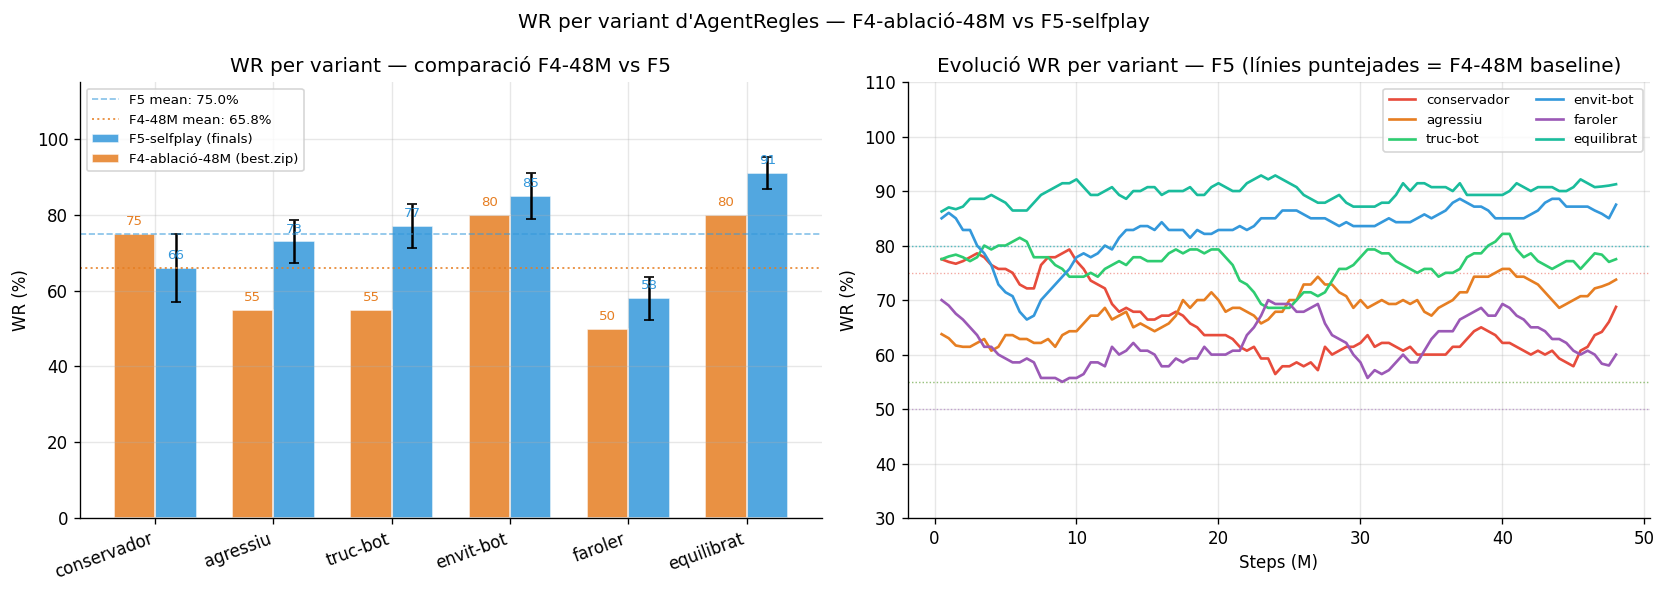


Variant          F4-48M best.zip    F5 finals        Δ
--------------------------------------------------------
  conservador                75.0% 66.0%     -9.0
  agressiu                   55.0% 73.0%    +18.0
  truc-bot                   55.0% 77.0%    +22.0
  envit-bot                  80.0% 85.0%     +5.0
  faroler                    50.0% 58.0%     +8.0
  equilibrat                 80.0% 91.0%    +11.0

  metric_robust   59.5%           77.8%  +18.3 pp


In [8]:
df_f5 = dades.get('f5_selfplay')
if df_f5 is not None:
    cols_var   = [f'wr_{v}' for v in VARIANTS]
    labels_var = [v.replace('_', '-') for v in VARIANTS]

    f5_final = df_f5[cols_var].tail(5).mean().values
    f5_std   = df_f5[cols_var].tail(5).std().values
    f4_final = np.array([wr_f4_variants.get(v, float('nan')) for v in VARIANTS])
    has_f4   = bool(wr_f4_variants)

    # Barplot comparatiu F4 vs F5
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('WR per variant d\'AgentRegles — F4-ablació-48M vs F5-selfplay', fontsize=12)

    ax = axes[0]
    x  = np.arange(len(VARIANTS))
    w  = 0.35
    bars_f5 = ax.bar(x + w/2, f5_final, w, color=RUNS['f5_selfplay']['color'],
                     alpha=0.85, edgecolor='white', label='F5-selfplay (finals)', yerr=f5_std, capsize=3)
    if has_f4:
        bars_f4 = ax.bar(x - w/2, f4_final, w, color=RUNS['f4_ablacio_48M']['color'],
                         alpha=0.85, edgecolor='white', label='F4-ablació-48M (best.zip)')
        for bar, val in zip(bars_f4, f4_final):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                        f'{val:.0f}', ha='center', va='bottom', fontsize=8,
                        color=RUNS['f4_ablacio_48M']['color'])
    for bar, val in zip(bars_f5, f5_final):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8,
                color=RUNS['f5_selfplay']['color'])
    ax.axhline(f5_final.mean(), color=RUNS['f5_selfplay']['color'],
               linestyle='--', linewidth=1, alpha=0.6,
               label=f"F5 mean: {f5_final.mean():.1f}%")
    if has_f4:
        ax.axhline(f4_final.mean(), color=RUNS['f4_ablacio_48M']['color'],
                   linestyle=':', linewidth=1.2, alpha=0.8,
                   label=f"F4-48M mean: {f4_final.mean():.1f}%")
    ax.set_xticks(x)
    ax.set_xticklabels(labels_var, rotation=20, ha='right')
    ax.set_ylabel('WR (%)')
    ax.set_title('WR per variant — comparació F4-48M vs F5')
    ax.set_ylim(0, 115)
    ax.legend(fontsize=8)

    # Corba WR per variant al llarg del temps (F5)
    ax = axes[1]
    colors_var = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db', '#9b59b6', '#e84393']
    s = df_f5['step'] / 1e6
    for col_v, nom, c in zip(cols_var, labels_var, colors_var):
        ax.plot(s, suavitzar(df_f5[col_v], 7), color=c, linewidth=1.6, label=nom)
        if has_f4 and nom.replace('-', '_') in wr_f4_variants:
            ax.axhline(wr_f4_variants[nom.replace('-', '_')], color=c,
                       linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('WR (%)')
    ax.set_title('Evolució WR per variant — F5 (línies puntejades = F4-48M baseline)')
    ax.set_ylim(30, 110)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    print(f"\n{'Variant':<15} {'F4-48M best.zip':>16} {'F5 finals':>12} {'Δ':>8}")
    print("-" * 56)
    for nom, vf4, vf5 in zip(labels_var, f4_final, f5_final):
        delta = vf5 - vf4 if not np.isnan(vf4) else float('nan')
        delta_str = f"{delta:+.1f}" if not np.isnan(delta) else "—"
        vf4_str   = f"{vf4:.1f}%" if not np.isnan(vf4) else "—"
        print(f"  {nom:<15} {vf4_str:>16} {vf5:.1f}% {delta_str:>8}")
    print(f"\n  {'metric_robust':<15} {f4_metric_robust:.1f}%{'':>10} {df_f5['metric_robust'].max():.1f}%"
          f"  {df_f5['metric_robust'].max()-f4_metric_robust:>+.1f} pp")


---
## 6. Explotabilitat self-play

`exploit_selfplay = |WR_vs_recent_snapshots − 50|` mesura la distància al Nash local.
- **0 pp** = Nash perfecte (cap versió passada pot explotar la present).
- **Alta i creixent** = cycling (l'agent atual domina les versions anteriors, senyal d'inestabilitat).
- `wr_vs_self` ≈ 50% és l'objectiu; nan fins al primer snapshot (step 1M).

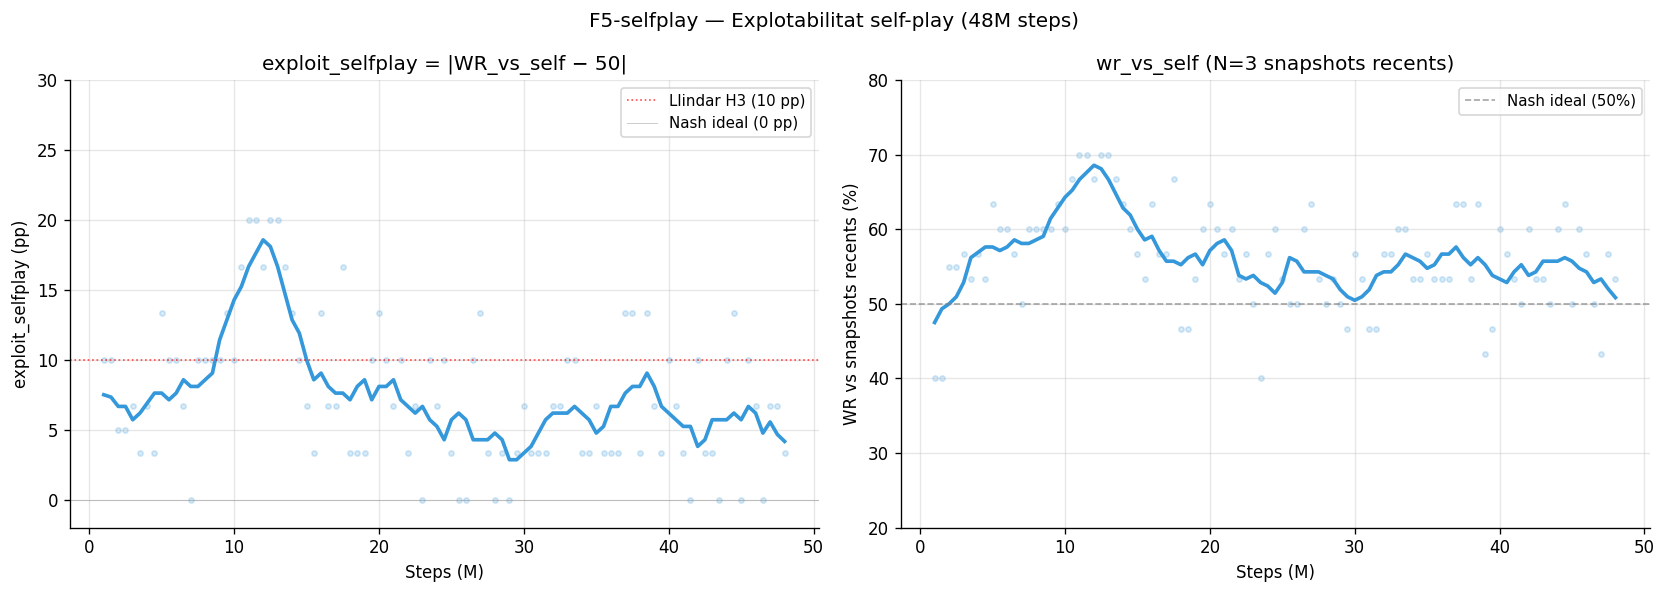

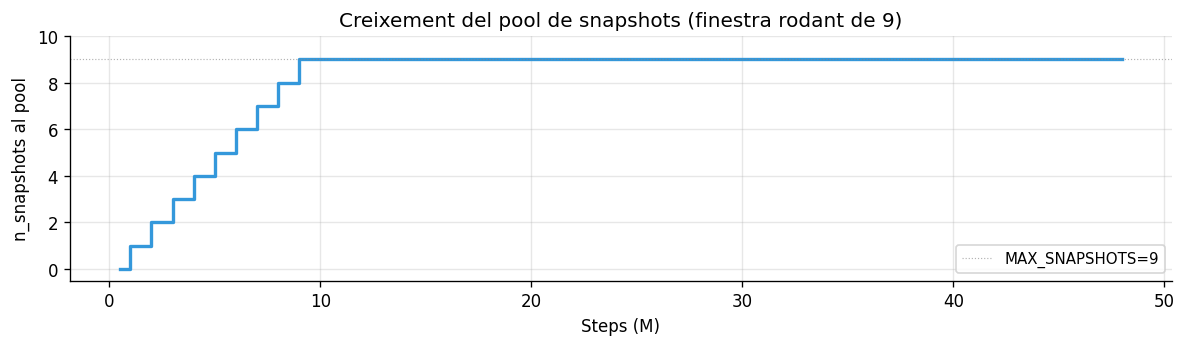

In [9]:
df_f5 = dades.get('f5_selfplay')
if df_f5 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('F5-selfplay — Explotabilitat self-play (48M steps)', fontsize=12)
    s    = df_f5['step'] / 1e6
    col  = RUNS['f5_selfplay']['color']
    mask = df_f5['exploit_selfplay'].notna()

    # exploit_selfplay
    ax = axes[0]
    ax.scatter(s[mask], df_f5['exploit_selfplay'][mask], color=col, alpha=0.2, s=10)
    ax.plot(s[mask], suavitzar(df_f5['exploit_selfplay'][mask].reset_index(drop=True), 7),
            color=col, linewidth=2.2)
    ax.axhline(10, color='red', linestyle=':', linewidth=1, alpha=0.7, label='Llindar H3 (10 pp)')
    ax.axhline(0,  color='gray', linestyle='-', linewidth=0.6, alpha=0.4, label='Nash ideal (0 pp)')
    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('exploit_selfplay (pp)')
    ax.set_title('exploit_selfplay = |WR_vs_self − 50|')
    ax.set_ylim(-2, 30)
    ax.legend(fontsize=9)

    # wr_vs_self
    ax = axes[1]
    ax.scatter(s[mask], df_f5['wr_vs_self'][mask], color=col, alpha=0.2, s=10)
    ax.plot(s[mask], suavitzar(df_f5['wr_vs_self'][mask].reset_index(drop=True), 7),
            color=col, linewidth=2.2)
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Nash ideal (50%)')
    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('WR vs snapshots recents (%)')
    ax.set_title('wr_vs_self (N=3 snapshots recents)')
    ax.set_ylim(20, 80)
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # n_snapshots al pool
    fig2, ax2 = plt.subplots(figsize=(10, 3))
    ax2.step(s, df_f5['n_snapshots'], color=col, linewidth=2, where='post')
    ax2.set_xlabel('Steps (M)')
    ax2.set_ylabel('n_snapshots al pool')
    ax2.set_title('Creixement del pool de snapshots (finestra rodant de 9)')
    ax2.set_ylim(-0.5, 10)
    ax2.axhline(9, color='gray', linestyle=':', linewidth=0.7, alpha=0.6, label='MAX_SNAPSHOTS=9')
    ax2.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 7. Taula resum

In [38]:
rows = []

df_f4_48M_log = dades.get('f4_ablacio_48M')
df_f5         = dades.get('f5_selfplay')

# F4-ablació 48M
if df_f4_48M_log is not None:
    pic      = df_f4_48M_log['metric'].max()
    step_pic = df_f4_48M_log.loc[df_f4_48M_log['metric'].idxmax(), 'step'] / 1e6
    temps_h  = df_f4_48M_log['elapsed'].max() / 3600
    mr_log   = df_f4_48M_log['metric_robust'].max()
    mr_step  = df_f4_48M_log.loc[df_f4_48M_log['metric_robust'].idxmax(), 'step'] / 1e6
    std_m    = df_f4_48M_log['std_pool'].mean()
    mr_best  = f4_metric_robust  # avaluació puntual del best.zip
    rows.append({
        'Run':                        'F4-ablació-48M (baseline)',
        'Steps':                      '48M',
        'Pic metric (%)':             f'{pic:.1f}',
        'Step pic (M)':               f'{step_pic:.1f}',
        'Pic MR log (%)':             f'{mr_log:.1f} (@{mr_step:.0f}M)',
        'MR best.zip (%)':            f'{mr_best:.1f}' if not np.isnan(mr_best) else '—',
        'std_pool mitjana (%)':       f'{std_m:.1f}',
        'exploit_sp (pp)':            '—',
        'Temps (h)':                  f'{temps_h:.2f}',
    })

# F5-selfplay
if df_f5 is not None:
    pic_full = df_f5['metric'].max()
    pic_12   = df_f5[df_f5['step'] <= 48e6]['metric'].max()
    step_pic = df_f5.loc[df_f5['metric'].idxmax(), 'step'] / 1e6
    temps_h  = df_f5['elapsed'].max() / 3600
    mr_pic   = df_f5['metric_robust'].max()
    mr_step  = df_f5.loc[df_f5['metric_robust'].idxmax(), 'step'] / 1e6
    std_m    = df_f5['std_pool'].mean()
    valid    = df_f5['exploit_selfplay'].dropna()
    exp_fin  = valid.iloc[-5:].mean() if not valid.empty else float('nan')
    delta    = mr_pic - f4_metric_robust if not np.isnan(f4_metric_robust) else float('nan')
    rows.append({
        'Run':                        'F5-selfplay (9 snaps)',
        'Steps':                      '48M',
        'Pic metric (%)':             f'{pic_full:.1f}  (12M: {pic_12:.1f})',
        'Step pic (M)':               f'{step_pic:.1f}',
        'Pic MR log (%)':             f'{mr_pic:.1f} (@{mr_step:.0f}M)',
        'MR best.zip (%)':            f'+{delta:.1f}pp vs F4' if not np.isnan(delta) else '—',
        'std_pool mitjana (%)':       f'{std_m:.1f}',
        'exploit_sp (pp)':            f'{exp_fin:.1f}' if not np.isnan(exp_fin) else '—',
        'Temps (h)':                  f'{temps_h:.2f}',
    })

df_resum = pd.DataFrame(rows).set_index('Run')

def highlight_best(col):
    try:
        vals = col.str.extract(r'^(\d+\.\d+)', expand=False).astype(float)
        is_max = vals == vals.max()
        return ['font-weight: bold; color: green' if v else '' for v in is_max]
    except Exception:
        return ['' for _ in col]

display(df_resum.style.apply(highlight_best, subset=['Pic metric (%)']))

,Steps,Pic metric (%),Step pic (M),Pic MR log (%),MR best.zip (%),std_pool mitjana (%),exploit_sp (pp),Temps (h)
Run,,,,,,,,
F4-ablació-48M (baseline),48M,89.0,24.0,73.2 (@12M),59.5,11.3,—,1.41
F5-selfplay (9 snaps),48M,89.2 (12M: 89.2),41.5,77.8 (@40M),+18.3pp vs F4,11.5,4.7,1.69


---
## 8. Conclusions

### 8.1 Validació d'hipòtesis

| Hipòtesi | Criteri | Resultat | Validada? |
|:--|:--|--:|:--|
| **H1** — Self-play no degrada WR global | max metric F5@≤48M >= max F4@≤48M − 3pp | F5=87.0% vs F4=86.0% (llindar 83%) | **Sí** |
| **H2** — Self-play millora metric\_robust | metric\_robust F5 pic > F4-48M best.zip | F4=59.5% : F5=77.8% (+18.3 pp) | **Sí** |
| **H3** — exploit\_selfplay final < 10 pp | mean últims 5 punts < 10pp | 4.7 pp | **Sí** |

*H1 usa el màxim acumulat fins als 12M steps. F5 parteix del best.zip de F4 (warm-start).*

### 8.2 Resum quantitatiu

| Run | Steps | Pic metric | Step pic | Pic MR log | MR best.zip | std\_pool | exploit\_sp | Temps |
|:--|--:|--:|--:|--:|--:|--:|--:|--:|
| F4-ablació-48M | 48M | 89.0% | 24M | 73.2% (@12M) | **59.5%** | ~10.4% | — | 1.41h |
| **F5-selfplay** | 48M | **89.2%** | 41.5M | **77.8%** (@39.5M) | +18.3pp | ~11.5% | **4.7 pp** | 1.69h |

**Columnes**: *Pic MR log* = màxim de metric\_robust al llarg de l'entrenament. *MR best.zip* = metric\_robust del model guardat com a millor classic metric.

### 8.3 Interpretació

**H1 — metric clàssica**: El warm-start fa que F5 tingui rendiment inicial alt des del primer step. Màxim acumulat als primers 12M: F5=87.0% vs F4=86.0%. Pic global: F4=89.0% vs F5=89.2%. Self-play **no degrada** el rendiment.

**H2 — metric\_robust**: Resultat més rellevant. El `best.zip` de F4 (guardat al pic de metric clàssica @24M) té `metric_robust=59.5%` — el model que maximitza el rendiment contra AgentRegles estàndard és precisament el **més especialitzat** (std=12.7%). En canvi, el pic de metric\_robust al training\_log de F4 és 73.2% (@12M), però el model degrada fins a 62.6% als 48M per overfit. F5 assoleix `metric_robust=77.8%` (@39.5M, +18.3pp sobre F4 best.zip).

**H3 — exploit\_selfplay**: Mean últims 5 punts = 4.7 pp < 10 pp. Cycling suau (0–13pp). Simplified FSP no garanteix convergència monòtona a Nash.

**Observació clau — trade-off robustesa vs rendiment a F4**: El model de F4 que millor jugue (best.zip, metric=89.0%) no és el més robust (metric_robust=59.5%). El self-play de F5 trenca aquest trade-off: assoleix rendiment equivalent (89.2%) i robustesa molt superior (77.8%).

### 8.4 Limitació: std\_pool persistent

La `std_pool` no disminueix durant l'entrenament (~10–15%). La solució és el **NFSP complet** (Fase 6):
- Un agent **SL** aprèn la política promig via reservoir buffer.
- L'agent **RL** entrena contra la barreja α·SL + (1−α)·RL.
- Convergència demostrada a Nash en jocs 2-jugadors zero-sum (Heinrich & Silver, 2016).

### 8.5 Resposta a Q4

> **Q4**: Pot el self-play mixt reduir l'explotabilitat del PPO sense degradar el rendiment global?

**Sí**. El self-play mixt (Simplified FSP, 9 snapshots):
- **No degrada** el rendiment (H1: F5 max@12M=87.0% ≥ F4-3pp=83.0%).
- **Millora substancialment** la robustesa (H2: +18.3pp sobre F4 best.zip).
- **Trenca el trade-off** de F4: millor rendiment global I millor robustesa simultàniament.
- **Manté** l'explotabilitat en nivells acceptables (H3: 4.7 pp).

La convergència a Nash requereix el component SL de **Fase 6 (NFSP complet)**.

### 8.6 Enllaços creuats

- [`17_Fase5_MarcTeoric`](../../17_Fase5_MarcTeoric.md) — fonaments teòrics: FSP, mètriques d'explotabilitat.
- [`18_Fase5_Implementacio`](../../18_Fase5_Implementacio.md) — detalls tècnics d'implementació.
- [`comparacio_fase4.ipynb`](../4_memoria/comparacio_fase4.ipynb) — F4-ablació: model de partida.